# ECLAT Software

# Librerias

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
from collections import defaultdict

# Clases

In [18]:
from src.utils import path

# Funciones

In [19]:
def build_vertical_db(transactions):
    """Construye la base de datos vertical (TID-list) a partir de las transacciones."""
    vertical_db = defaultdict(set)
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            vertical_db[frozenset([item])].add(tid)
    return dict(vertical_db)


def eclat(prefix, items, min_support, frequent_itemsets, n_transactions):
    """Búsqueda recursiva en profundidad de itemsets frecuentes."""
    while items:
        item, tid_set = items.pop(0)
        new_prefix = prefix | item
        support = len(tid_set)

        if support >= min_support:
            frequent_itemsets[new_prefix] = {
                "support_count": support,
                "support_pct": round(support / n_transactions, 4),
            }
            suffix = []
            for other_item, other_tid_set in items:
                new_tid_set = tid_set & other_tid_set
                if len(new_tid_set) >= min_support:
                    suffix.append((other_item, new_tid_set))
            if suffix:
                eclat(new_prefix, suffix, min_support,
                      frequent_itemsets, n_transactions)


def run_eclat(transactions, min_support=0.3):
    """Ejecuta ECLAT y devuelve los itemsets frecuentes."""
    n = len(transactions)
    min_sup_count = max(1, int(min_support * n))
    vertical_db = build_vertical_db(transactions)

    frequent_1 = {
        item: tids
        for item, tids in vertical_db.items()
        if len(tids) >= min_sup_count
    }

    frequent_itemsets = {
        item: {"support_count": len(tids),
               "support_pct": round(len(tids) / n, 4)}
        for item, tids in frequent_1.items()
    }

    items_list = sorted(frequent_1.items(), key=lambda x: str(sorted(x[0])))
    eclat(frozenset(), items_list, min_sup_count, frequent_itemsets, n)
    return frequent_itemsets


def generate_rules(frequent_itemsets, min_confidence=0.6):
    """Genera reglas de asociación a partir de los itemsets frecuentes."""
    rules = []
    for itemset, stats in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for size in range(1, len(itemset)):
            for antecedent in combinations(sorted(itemset), size):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent
                if antecedent in frequent_itemsets:
                    ant_sup = frequent_itemsets[antecedent]["support_count"]
                    confidence = stats["support_count"] / ant_sup
                    if confidence >= min_confidence:
                        con_sup_pct = frequent_itemsets.get(
                            consequent, {}).get("support_pct")
                        lift = round(confidence / con_sup_pct, 4) \
                            if con_sup_pct else None
                        rules.append({
                            "antecedents": set(antecedent),
                            "consequents": set(consequent),
                            "support":     stats["support_pct"],
                            "confidence":  round(confidence, 4),
                            "lift":        lift,
                        })
    return sorted(rules, key=lambda r: r["confidence"], reverse=True)


def results_to_df(frequent_itemsets, rules):
    """Convierte los resultados a DataFrames de pandas."""
    df_items = pd.DataFrame([
        {
            "itemset": ", ".join(sorted(k)),
            "tamaño":  len(k),
            "support_count": v["support_count"],
            "support": v["support_pct"],
        }
        for k, v in frequent_itemsets.items()
    ]).sort_values(["tamaño", "support_count"], ascending=[True, False])

    df_rules = pd.DataFrame([
        {
            "antecedents": frozenset(r["antecedents"]),
            "consequents": frozenset(r["consequents"]),
            "support":     r["support"],
            "confidence":  r["confidence"],
            "lift":        r["lift"],
        }
        for r in rules
    ])

    return df_items, df_rules

# Lectura de DF procesado

In [20]:
directorio_proyecto = path.obtener_ruta_local()
datos = pd.read_csv(directorio_proyecto+'\\data\\processed\\Software.csv',delimiter = ',',decimal = ".", encoding='utf-8')
datos.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Reglas
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,"EMEA,UKIR,Energy,SMB,Marketing Suite"
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820,"EMEA,UKIR,Energy,SMB,FinanceHub"
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714,"AMER,NAMER,Energy,Strategic,FinanceHub"
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310,"EMEA,EU-WEST,Energy,SMB,ContactMatcher"
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164,"EMEA,EU-WEST,Energy,SMB,Marketing Suite - Gold"


In [21]:
df_reglas_software = datos[["Reglas"]]
df_reglas_software.head()

,Reglas
0,"EMEA,UKIR,Energy,SMB,Marketing Suite"
1,"EMEA,UKIR,Energy,SMB,FinanceHub"
2,"AMER,NAMER,Energy,Strategic,FinanceHub"
3,"EMEA,EU-WEST,Energy,SMB,ContactMatcher"
4,"EMEA,EU-WEST,Energy,SMB,Marketing Suite - Gold"


In [22]:
df_reglas_software.shape

(9994, 1)

In [23]:
data_software = list(
    df_reglas_software["Reglas"].apply(lambda x: [i.strip() for i in str(x).split(",")])
)
data_software[:3]

[['EMEA', 'UKIR', 'Energy', 'SMB', 'Marketing Suite'],
 ['EMEA', 'UKIR', 'Energy', 'SMB', 'FinanceHub'],
 ['AMER', 'NAMER', 'Energy', 'Strategic', 'FinanceHub']]

In [24]:
# Establezca un valor umbral para el soporte mínimo y ejecute ECLAT
frequent_itemsets_software = run_eclat(data_software, min_support=0.2)
df_itemsets_software, _ = results_to_df(frequent_itemsets_software, [])
df_itemsets_software

,itemset,tamaño,support_count,support
1,SMB,1,5191,0.5194
0,EMEA,1,4219,0.4222
2,AMER,1,3665,0.3667
4,Strategic,1,3020,0.3022
3,NAMER,1,2507,0.2509
5,Finance,1,2127,0.2128
6,APJ,1,2110,0.2111
7,"AMER, NAMER",2,2507,0.2509
8,"EMEA, SMB",2,2180,0.2181


In [26]:
# Reglas de asociación con umbral de confianza mínima
rules_software = generate_rules(frequent_itemsets_software, min_confidence=0.5)
_, df_ar_software = results_to_df(frequent_itemsets_software, rules_software)
df_ar_software

,antecedents,consequents,support,confidence,lift
0,frozenset({NAMER}),frozenset({AMER}),0.2509,1.0000,2.7270
1,frozenset({AMER}),frozenset({NAMER}),0.2509,0.6840,2.7263
2,frozenset({EMEA}),frozenset({SMB}),0.2181,0.5167,0.9948


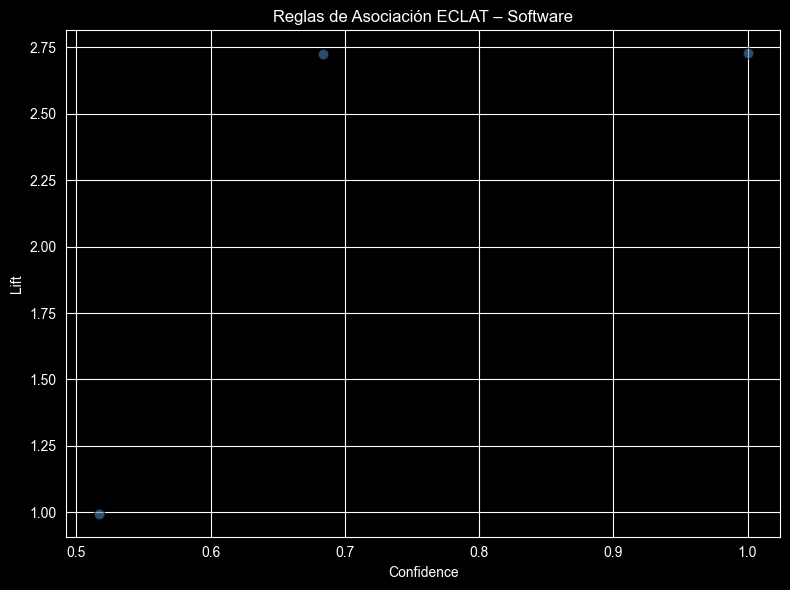

In [27]:
# Scatter plot de confidence vs lift
plt.figure(figsize=(8, 6))
plt.scatter(df_ar_paquete["confidence"], df_ar_paquete["lift"],
            alpha=0.6, c="steelblue", edgecolors="k", s=60)
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Reglas de Asociación ECLAT – Software")
plt.tight_layout()
plt.show()

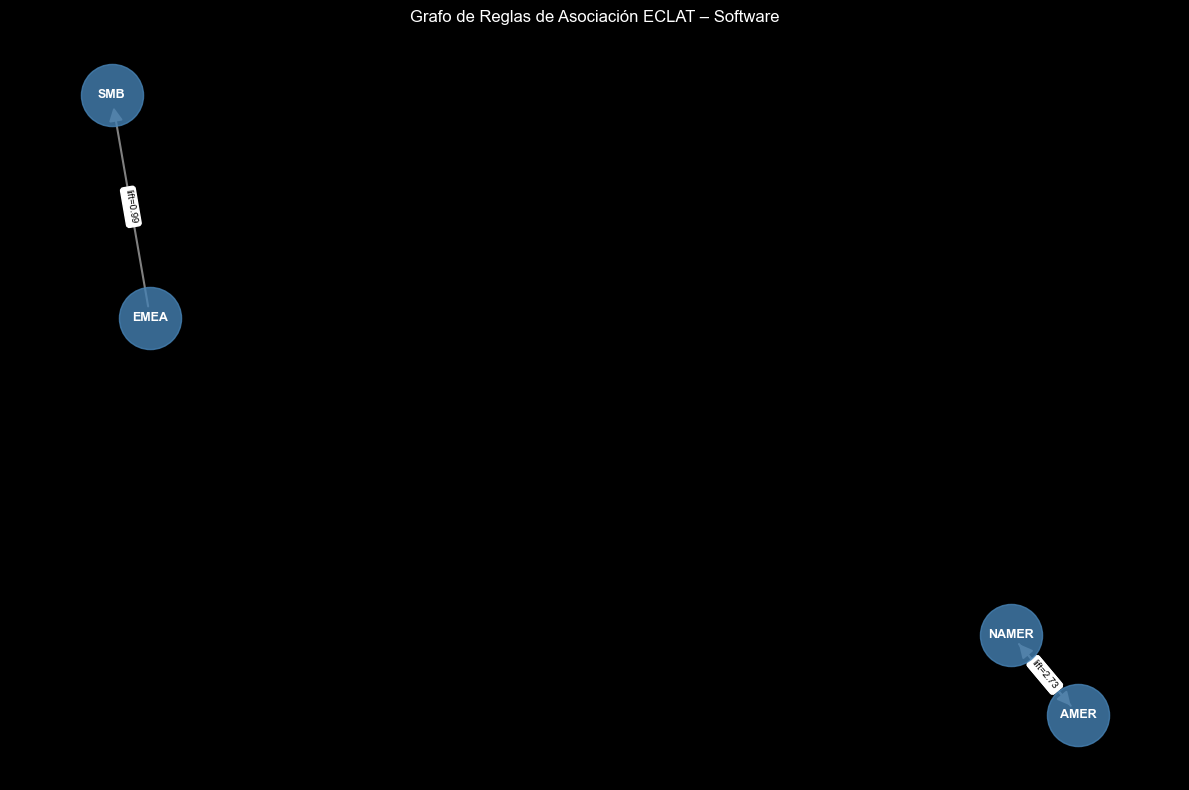

In [28]:
# Visualización de reglas como grafo de red
G = nx.DiGraph()
for _, row in df_ar_software.iterrows():
    ant = ", ".join(sorted(row["antecedents"]))
    con = ", ".join(sorted(row["consequents"]))
    G.add_edge(ant, con, weight=row["lift"])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="steelblue", alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                       arrowsize=20, width=1.5)
edge_labels = {(u, v): f"lift={d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Grafo de Reglas de Asociación ECLAT – Software")
plt.axis("off")
plt.tight_layout()
plt.show()